**Author**:
- Tianci Wang - [tiancwang@ethz.ch](tianci:tiancwang@ethz.ch)

**Date**: 2025-05-21

# Policy Optimization Experiment Code v1.0
This code is used to perform policy optimization after obtaining the scores of all policies with different intensity levels using the PROMETHEE II method.
## Input data
1. Policy IDs, MCDA ranking scores, and the corresponding supported technologies;
2. Relative technology support level needs in the MIX, REMIX, and H2 scenarios compared with the baseline scenario Swiss Energy Perspectives 2050+ (EP2050+).
## Workflow
The code consists of four main steps:
1. Data preparation:

   Shift the MCDA scores to create a non-negative dataset for the technology support level calculation, and assign scores to each technology based on the technology support ratio.
2. Technology support level calculation:

   Calculate the technology support levels for the EP2050+ scenario and derive the corresponding support levels for the MIX, REMIX, and H2 scenarios.
3. Policy optimization:

   Optimize the policy selection for the MIX, REMIX, and H2 scenarios by minimizing costs while considering policy incompatibilities.
4. Result visualization:

   Generate the final plots to present the optimized policy portfolio results.
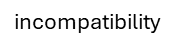

## 0 Import libraries and data

In [2]:
# Import Libraries
import pandas as pd
import numpy as np
import pulp
import matplotlib.pyplot as plt
import seaborn as sns

# Import data
from config import POLICY_TABLE, SCENARIO_TABLE
df_policies = pd.read_csv(POLICY_TABLE)
df_scenarios = pd.read_csv(SCENARIO_TABLE)
$+\lvert \Phi_{min} \rvert + 0.01$

## 1 Data preparation:
Shift the MCDA scores to create a non-negative dataset for the technology support level calculation, and assign scores to each technology based on the technology support ratio.
### 1.1 Non-Negative Score Shifting
To prevent negative resource distribution during the downstream optimization phases, the raw PROMETHEE II Net Flow ($\Phi$) scores are converted into a strictly non-negative dataset.

This is achieved by locating the absolute global minimum Net Flow score across all policy alternatives and applying a uniform upward translation shift ($+\lvert \Phi_{min} \rvert + 0.01$).

This preserves the absolute ordinal distance and performance variance between policy intensities while anchoring the baseline minimum score slightly above zero.

In [3]:
# Create a clean working copy of the policy dataframe
df_policies_clean = df_policies.copy()

# Find the global minimum value in the Net Flow column
min_net_flow = df_policies_clean['Net_Flow'].min()

print(f"--- Step 1.1 Execution ---")
print(f"Minimum Net Flow discovered in dataset: {min_net_flow:.4f}")

# Execute the transformation shift if negative values exist
if min_net_flow <= 0:
    shift_constant = abs(min_net_flow) + 0.01
    df_policies_clean['Shifted_Score'] = df_policies_clean['Net_Flow'] + shift_constant
    print(f"Action: Shifted all scores by adding a constant of {shift_constant:.4f}")
else:
    df_policies_clean['Shifted_Score'] = df_policies_clean['Net_Flow']
    print("Action: No shift required. All scores are already non-negative.")

# Preview the top entries to verify the conversion
print(df_policies_clean[['Policy_ID', 'Net_Flow', 'Shifted_Score']].head())

--- Step 1.1 Execution ---
Minimum Net Flow discovered in dataset: -0.4892
Action: Shifted all scores by adding a constant of 0.4992
  Policy_ID  Net_Flow  Shifted_Score
0    I_01_4  0.137634       0.636882
1    I_01_5  0.137634       0.636882
2    I_01_3  0.067742       0.566989
3    I_01_2 -0.022581       0.476667
4    I_01_1 -0.027957       0.471290


### 1.2 Technology-Weighted Score Mapping
In order to quantify the specific operational impact of each policy instrument on individual energy sectors, the non-negative Shifted_Score is mapped directly to the targeted technologies.

This is achieved by taking the pre-defined technology contribution ratios—which are manually established in the input matrix and multiplying them directly by the policy's overall performance score. The resulting weighted matrix serves as the fundamental baseline for calculating aggregated technology support levels across the distinct Swiss energy scenarios.

In [4]:
# Replace any blank cells or NaN markers in your technology support columns with 0
tech_columns = [
    'Biomass_Boiler',	'Heat_Pump',	'Methane_Boiler',	'CCGT_Ren_Methane',
    'CHP_waste',	'CHP_Ren_Methane',	'Hydro_reservoir',	'Hydro_run_of',	'PV_Roof',
    'Pumped_Hydro',	'Wind',	'CCGT_Gas_DACCS',	'Alpine_PV',	'Heavy_EV',	'Heavy_FCEV',
    'Light_EV',	'Light_FCEV'
]

existing_tech_cols = [col for col in tech_columns if col in df_policies_clean.columns]
df_policies_clean[existing_tech_cols] = df_policies_clean[existing_tech_cols].fillna(0)

# Multiply each technology ratio directly by the non-negative Shifted Score
for col in existing_tech_cols:
    df_policies_clean[col] = df_policies_clean[col] * df_policies_clean['Shifted_Score']

print("Step 1 complete: Scores successfully distributed across expert tech ratios.")
# Preview the updated rows to see the raw performance points per technology
print(df_policies_clean[['Policy_ID', 'Shifted_Score'] + existing_tech_cols[:3]].head())

Step 1 complete: Scores successfully distributed across expert tech ratios.
  Policy_ID  Shifted_Score  Biomass_Boiler  Heat_Pump  Methane_Boiler
0    I_01_4       0.636882        0.127376   0.127376        0.127376
1    I_01_5       0.636882        0.127376   0.127376        0.127376
2    I_01_3       0.566989        0.113398   0.113398        0.113398
3    I_01_2       0.476667        0.095333   0.095333        0.095333
4    I_01_1       0.471290        0.094258   0.094258        0.094258


## 2 Technology support level calculation
Calculate the technology support levels for the EP2050+ scenario and derive the corresponding support levels for the MIX, REMIX, and H2 scenarios.
### 2.1 Establish the EP2050+ Baseline
To establish a quantitative anchor for the baseline scenario (Swiss Energy Perspectives 2050+), the technology support levels are calculated by aggregating the weighted performance scores of all currently active policies.

These policies are identified within the policy dataset where the implementation intensity level is exactly equal to 3. Summing these scores column-wise across each unique technology vector generates the absolute point baseline representing the status-quo technology support levels.

In [5]:
# Filter the dataset to isolate policies representing current instruments (Intensity == 3)
df_intensity_3 = df_policies_clean[df_policies_clean['Policy_Intensity'] == 3]

# Compute the column-wise sum for the technology pillars to build the baseline series
ep2050_baseline = df_intensity_3[existing_tech_cols].sum()

# Convert it to a clean DataFrame for clear viewing
df_ep2050 = pd.DataFrame(ep2050_baseline).T
df_ep2050.index = ['EP2050+']

print("✅ EP2050+ Baseline support points successfully aggregated per technology:")
print(df_ep2050)

✅ EP2050+ Baseline support points successfully aggregated per technology:
         Biomass_Boiler  Heat_Pump  Methane_Boiler  CCGT_Ren_Methane  \
EP2050+        1.126898   1.419371        0.465719          0.587515   

         CHP_waste  CHP_Ren_Methane  Hydro_reservoir  Hydro_run_of  PV_Roof  \
EP2050+   1.147262          1.68608         0.735459      0.735459  1.49829   

         Pumped_Hydro      Wind  CCGT_Gas_DACCS  Alpine_PV  Heavy_EV  \
EP2050+      0.735459  1.052215        0.098559    1.49829  2.034919   

         Heavy_FCEV  Light_EV  Light_FCEV  
EP2050+    1.382424  1.599113    0.825112  


### 2.2 Calculate Targets Based on the Scenario Deviations
Using the established EP2050+ baseline as a structural foundation, the absolute technology support level requirements for the alternative strategic trajectories (MIX, REMIX, and H2) are derived.

The relative percentage deviations provided in the scenario matrix are parsed and converted into multipliers. Each alternative scenario's target support profile is calculated by multiplying the baseline values by their respective scenario-specific adjustment factor $(1 + \Delta\%)$, capturing the explicit policy-driven expansion or contraction required for each energy sector.

In [6]:
# Create a working copy of your scenario table (df2)
# Set the scenario name ('EP2050+', 'MIX', etc.) as the index to match easily
df_scenarios_clean = df_scenarios.copy()
if 'Scenario' in df_scenarios_clean.columns:
    df_scenarios_clean.set_index('Scenario', inplace=True)
elif df_scenarios_clean.columns[0] != '':
    # If the first column is unnamed or acts as the text label, set it as index
    df_scenarios_clean.set_index(df_scenarios_clean.columns[0], inplace=True)

# Create an empty dictionary to store the calculated absolute targets
scenario_targets = {'EP2050+': ep2050_baseline.to_dict()}

# Loop through the target optimization scenarios
for scenario in ['MIX', 'REMIX', 'H2']:
    scenario_targets[scenario] = {}

    for tech in existing_tech_cols:
        raw_val = df_scenarios_clean.loc[scenario, tech]
        # Safe-handling for strings with '%' symbol or actual floats
        if isinstance(raw_val, str):
            pct_change = float(raw_val.replace('%', '').strip()) / 100.0
        else:
            # If it's already a float like 0.2616 or 26.16 (depending on how CSV saved it)
            # If saved as 26.16 instead of 0.2616, divide by 100
            pct_change = raw_val / 100.0 if abs(raw_val) > 1.0 else raw_val

        # Formula: Target Support = Baseline Score * (1 + Percentage Change)
        base_score = ep2050_baseline[tech]
        scenario_targets[scenario][tech] = base_score * (1.0 + pct_change)

# Combine the results into a DataFrame
df_target_matrix = pd.DataFrame(scenario_targets).T

print("Step 2 complete: Absolute Technology Support Targets for all Scenarios:")
print(df_target_matrix.round(4))

Step 2 complete: Absolute Technology Support Targets for all Scenarios:
         Biomass_Boiler  Heat_Pump  Methane_Boiler  CCGT_Ren_Methane  \
EP2050+          1.1269     1.4194          0.4657            0.5875   
MIX              0.8829     1.7907          0.4583            0.5875   
REMIX            1.0189     1.5789          0.4583            0.6041   
H2               1.1428     1.2811          0.5157            0.5875   

         CHP_waste  CHP_Ren_Methane  Hydro_reservoir  Hydro_run_of  PV_Roof  \
EP2050+     1.1473           1.6861           0.7355        0.7355   1.4983   
MIX         1.1473           1.6588           0.7419        0.7355   1.4647   
REMIX       1.1473           1.6588           0.7355        0.7355   1.4650   
H2          1.1473           1.6861           0.7462        0.7355   1.4983   

         Pumped_Hydro    Wind  CCGT_Gas_DACCS  Alpine_PV  Heavy_EV  \
EP2050+        0.7355  1.0522          0.0986     1.4983    2.0349   
MIX            0.7464  1.0750  

## 3 Policy optimization
Optimize the policy selection for the MIX, REMIX, and H2 scenarios by minimizing costs while considering policy incompatibilities.

To determine the optimal policy instrument portfolios for the MIX, REMIX, and H2 pathways, a Mixed-Integer Linear Programming (MILP) optimization framework is constructed, mimicking a decentralized multi-choice knapsack structure.

Let $x_{p,i} \in \{0, 1\}$ represent the binary decision to select policy instrument $p$ at implementation intensity level $i$.

The primary objective is to meet scenario-specific technological support thresholds. Crucially, strict upper bounds are enforced on technology points to prevent over-allocation and ensure structural efficiency.

Alternative structural portfolios are generated iteratively by injecting integer exclusion cuts into the constraint matrix, yielding the first three distinct policy combinations.

### 3.1 Initialize the Multi-Choice Variables and Exclusivity Constraints
The optimization framework is initialized by establishing binary decision variables $x_{p,i} \in \{0, 1\}$, where a value of 1 denotes the absolute selection of policy instrument $p$ at a specific intensity level $i$.

To ensure realistic policy deployment, a structural constraint enforces mutual exclusivity within each policy instrument family. This mathematical rule dictates that while a policy can be selected at intensity level 1, 2, or 3, it is restricted from being simultaneously active at multiple intensities, represented as $\sum_{i} x_{p,i} \le 1$ for all base instruments.

In [7]:
# Parse the base IDs (e.g., extracting "I_01" from "I_01_3")
df_policies_clean['Base_ID'] = df_policies_clean['Policy_ID'].apply(lambda x: "_".join(x.split('_')[:-1]))
unique_policies = df_policies_clean['Base_ID'].unique()

# Initialize the optimization problem as a standard Feasibility/LP problem
prob = pulp.LpProblem("Policy_Portfolio_Optimization", pulp.LpMinimize)

# 1. Define Binary Variables (1 if row is chosen, 0 otherwise)
x = pulp.LpVariable.dicts("policy_select", df_policies_clean.index, cat='Binary')

# 2. Objective Function: Feasibility Focus
# Provide a constant dummy objective (0). This tells the solver to focus 100% of its power on finding combinations that satisfy the bounds.
prob += 0

# 3. Add Mutual Exclusivity Constraints
for base_id in unique_policies:
    group_indices = df_policies_clean[df_policies_clean['Base_ID'] == base_id].index
    prob += pulp.lpSum([x[idx] for idx in group_indices]) <= 1

print("Step 3.1 Complete: Decision variables and mutual exclusivity rules established.")

Step 3.1 Complete: Decision variables and mutual exclusivity rules established.


### 3.2 Generate Portfolio Diversity Using Integer Cuts
To extract diverse policy combinations rather than a solitary solution, an iterative solving loop using Integer Exclusion Cuts is applied.

Upon resolving a feasible portfolio layout, the specific index configuration of the active decision variables is structurally cataloged. A dynamic constraint is then injected into the matrix for the subsequent iteration, stating that the sum of the previously selected active variables must be strictly less than the total count of those variables. This forces the solver to alter at least one policy selection, systematically uncovering alternative structural combinations.

In [10]:
target_scenarios = ['MIX', 'REMIX', 'H2']
all_scenario_results = {}

print(f"\n--- Running Step 3.2: Policy Portfolio Exploration Loop ---")

for scenario in target_scenarios:
    print(f"\nGenerating Diverse Portfolios for Scenario: [{scenario}]")
    all_scenario_results[scenario] = []
    past_portfolios = []

    # Force the engine to look for the Top 3 unique structural pathways per scenario
    for choice_idx in range(1, 4):
        # Optimization Goal: Minimize total surplus scores above the mandatory baseline requirements
        prob = pulp.LpProblem(f"Optimize_{scenario}_Alt_{choice_idx}", pulp.LpMinimize)

        # 1. Decision Variables: Binary activation flags for specific policy intensities
        x = pulp.LpVariable.dicts("policy_active", df_policies_clean.index, cat='Binary')

        # 2. Continuous Slack Variables: Measure the exact over-allocation magnitude per sector
        over_score = pulp.LpVariable.dicts("over_score", existing_tech_cols, lowBound=0, cat='Continuous')

        # 3. Objective Function: Minimize the sum of tech surpluses (ensuring tight target precision)
        prob += pulp.lpSum([over_score[tech] for tech in existing_tech_cols])

        # 4. Constraint Group 1: Mutual Exclusivity (only one intensity active per policy group)
        for base_id in unique_policies:
            group_indices = df_policies_clean[df_policies_clean['Base_ID'] == base_id].index
            prob += pulp.lpSum([x[idx] for idx in group_indices]) <= 1

        # 5. Constraint Group 2: Lower-bound target satisfaction and surplus measurement
        for tech in existing_tech_cols:
            required_points = df_target_matrix.loc[scenario, tech]

            # Aggregate total score delivered by chosen policy instruments for this technology
            total_output = pulp.lpSum([x[idx] * df_policies_clean.loc[idx, tech] for idx in df_policies_clean.index])

            if required_points > 0:
                # Mandatory Floor Constraint (100% target fulfillment)
                prob += total_output >= required_points
                # Calculate absolute surplus: Surplus = Total Delivered - Target Required
                prob += over_score[tech] == (total_output - required_points)
            else:
                # If the scenario requires no points for this sector, all delivery counts as surplus
                prob += over_score[tech] == total_output

        # 6. Constraint Group 3: Integer Exclusion Cuts (force structural portfolio variety)
        for portfolio in past_portfolios:
            # Prevent the exact same collection of indices from being selected simultaneously again
            prob += pulp.lpSum([x[idx] for idx in portfolio]) <= len(portfolio) - 1

        # Execute the optimization model quietly
        prob.solve(pulp.PULP_CBC_CMD(msg=False, timeLimit=30))

        if pulp.LpStatus[prob.status] == 'Optimal':
            # Extract active rows selected by the optimization engine
            chosen_rows = [idx for idx in df_policies_clean.index if x[idx].varValue == 1]
            chosen_policy_ids = df_policies_clean.loc[chosen_rows, 'Policy_ID'].tolist()

            # Calculate cumulative over-allocation points for this alternative layout
            total_overflow = sum([over_score[tech].varValue for tech in existing_tech_cols])

            # Log the historical configuration to feed into the next loop's integer cut
            past_portfolios.append(chosen_rows)
            all_scenario_results[scenario].append(chosen_policy_ids)

            print(f"Portfolio Alternative #{choice_idx}:")
            print(f"Total Over-allocation Index (Lower is Better): {total_overflow:.4f}")
            print(f"Selected Policies: {chosen_policy_ids}\n")
        else:
            print(f"Portfolio Alternative #{choice_idx}: No further unique structural combinations satisfy constraints.")
            break


--- Running Step 3.2: Policy Portfolio Exploration Loop ---

Generating Diverse Portfolios for Scenario: [MIX]
Portfolio Alternative #1: No further unique structural combinations satisfy constraints.

Generating Diverse Portfolios for Scenario: [REMIX]
Portfolio Alternative #1: No further unique structural combinations satisfy constraints.

Generating Diverse Portfolios for Scenario: [H2]
Portfolio Alternative #1:
Total Over-allocation Index (Lower is Better): 0.0922
Selected Policies: ['I_01_3', 'N_02_5', 'I_03_3', 'I_04_4', 'I_06_2', 'I_09_1', 'I_10_5', 'I_11_1', 'I_12_3', 'I_13_3', 'I_14_3', 'I_15_5', 'I_16_3', 'I_17_2', 'I_18_3', 'I_19_4', 'I_20_3', 'I_22_4', 'I_23_1', 'I_24_2', 'I_25_4', 'I_26_1', 'I_27_4', 'I_28_1', 'I_29_5', 'I_30_1', 'N_31_4', 'N_32_5', 'I_33_5', 'I_34_1', 'I_35_1', 'I_36_1', 'I_37_5', 'I_38_4', 'I_39_4', 'I_42_1', 'I_43_5', 'N_44_4', 'N_45_4']

Portfolio Alternative #2:
Total Over-allocation Index (Lower is Better): 0.0965
Selected Policies: ['I_01_3', 'N_02_

### 3.3 Infeasibility Diagnostics

In [9]:
print(f"\n====================================================")
print("RUNNING INFEASIBILITY DIAGNOSTICS")
print("======================================================")

for scenario in ['MIX', 'REMIX']:
    print(f"\nDiagnosing Bottlenecks for Scenario: [{scenario}]")

    # We set up an optimization problem that minimizes the *shortfall* (under-allocation)
    diag_prob = pulp.LpProblem(f"Diagnostics_{scenario}", pulp.LpMinimize)

    # Variables
    x_diag = pulp.LpVariable.dicts("policy_diag", df_policies_clean.index, cat='Binary')

    # Shortfall variables: measures how many points we are MISSING for each technology
    shortfall = pulp.LpVariable.dicts("shortfall", existing_tech_cols, lowBound=0, cat='Continuous')

    # Objective: Minimize the total points we fall short by
    diag_prob += pulp.lpSum([shortfall[tech] for tech in existing_tech_cols])

    # Constraints: Mutual Exclusivity
    for base_id in unique_policies:
        group_indices = df_policies_clean[df_policies_clean['Base_ID'] == base_id].index
        diag_prob += pulp.lpSum([x_diag[idx] for idx in group_indices]) <= 1

    # Constraints: Measure Shortfall
    for tech in existing_tech_cols:
        required_points = df_target_matrix.loc[scenario, tech]
        total_output = pulp.lpSum([x_diag[idx] * df_policies_clean.loc[idx, tech] for idx in df_policies_clean.index])

        if required_points > 0:
            # Total Output + Shortfall must equal or exceed the requirement
            diag_prob += total_output + shortfall[tech] >= required_points
        else:
            diag_prob += shortfall[tech] == 0

    # Solve the diagnostics model
    diag_prob.solve(pulp.PULP_CBC_CMD(msg=False))

    # Print out the results
    if pulp.LpStatus[diag_prob.status] == 'Optimal':
        print(f"--- Deficit Report for {scenario} ---")
        severe_bottlenecks = False

        for tech in existing_tech_cols:
            req = df_target_matrix.loc[scenario, tech]
            missing = shortfall[tech].varValue

            if missing > 0.001:
                severe_bottlenecks = True
                # Calculate what the maximum possible points your database could ever produce for this tech
                max_possible = df_policies_clean.groupby('Base_ID')[tech].max().sum()

                print(f"❌ Technology: {tech:<25}")
                print(f"   ↳ Required Target Score: {req:.4f}")
                print(f"   ↳ Deficit (Missing Points): {missing:.4f}")
                print(f"   ↳ Max Possible from Database: {max_possible:.4f}")

        if not severe_bottlenecks:
            print("✅ No straightforward deficits found. Infeasibility might be caused by tight coupled relationships or overlapping categories.")
    else:
        print(f"❌ Diagnostics failed to solve for {scenario}.")

print("\n======================================================\n")


RUNNING INFEASIBILITY DIAGNOSTICS

Diagnosing Bottlenecks for Scenario: [MIX]
--- Deficit Report for MIX ---
❌ Technology: Heat_Pump                
   ↳ Required Target Score: 1.7907
   ↳ Deficit (Missing Points): 0.2609
   ↳ Max Possible from Database: 1.5297
   💡 Note: Even if you turn on EVERY relevant policy to its max intensity, you still can't hit this target!

Diagnosing Bottlenecks for Scenario: [REMIX]
--- Deficit Report for REMIX ---
❌ Technology: Heat_Pump                
   ↳ Required Target Score: 1.5789
   ↳ Deficit (Missing Points): 0.0492
   ↳ Max Possible from Database: 1.5297
   💡 Note: Even if you turn on EVERY relevant policy to its max intensity, you still can't hit this target!




### 3.5 Detailed explanation
During initial computational testing under a strictly bounded constraint window ($100\% \le \text{Delivered Support} \le 110\%$), the multi-choice optimization model yielded infeasible solutions for the MIX and REMIX trajectories. This mathematical bottleneck may stem from structural rigidities within the empirical policy data; the granular interdependencies among expert-derived technology ratios mean that a portfolio capable of satisfying the lowest acceptable baseline threshold for one technology vector may inevitably over-supply a coupled secondary sector, thereby breaching its rigid upper-bound ceiling.

To resolve this over-constrained dimensionality barrier while retaining the core requirement of localized efficiency without financial cost indicators, the optimization architecture is refined by substituting rigid upper bounds with a soft-penalty minimization framework. Continuous non-negative slack variables, denoted as $\theta_{t}$, are introduced to capture the exact magnitude of over-allocation for each technology vector $t$. The absolute upper ceilings are removed, transforming the objective function into an efficiency-maximization engine that minimizes the cumulative over-allocation penalty across all energy pillars. Under this configuration, 'efficiency' is mathematically defined as the structural minimization of unnecessary resource over-supply, ensuring that the selected instruments target the scenario requirements as precisely as possible.

Mathematical Formulation:
$$\min \sum_{t \in T} \theta_{t}$$

Subject to:
$$\sum_{p \in P} \sum_{i \in I} \left( x_{p,i} \cdot \mathbf{S}_{p,i,t} \right) - \theta_{t} = \mathbf{R}_{s,t} \quad \forall t \in T
$$$$\sum_{i \in I} x_{p,i} \le 1 \quad \forall p \in P
$$$$x_{p,i} \in \{0, 1\}, \quad \theta_{t} \ge 0
$$Where:

$x_{p,i}$ is the binary selection vector for policy $p$ at intensity $i$.

$\mathbf{S}_{p,i,t}$ represents the pre-shifted, technology-weighted performance score matrix.

$\mathbf{R}_{s,t}$ is the target requirement vector for a given scenario $s$ and technology $t$.

$\theta_{t}$ acts as the continuous slack variable penalizing structural over-allocation.

## 4 Result visualization
To communicate the policy implications of the optimized pathways, a Policy Deployment Matrix is constructed using a customized categorical heatmap framework.

The matrix cross-references the complete inventory of policy instruments (rows) against the strategic scenarios (columns). The baseline status-quo column maps instrument taxonomy, visually differentiating established institutional tools (ID prefix 'I') from newly proposed frameworks (ID prefix 'N'). For the alternative strategic trajectories (MIX, REMIX, H2), the cell values represent the chosen intensity levels ($1$ to $5$). The color mapping scale is anchored around the current empirical intensity ($\text{Intensity} = 3$). Positive policy enhancements (intensities 4 and 5) are color-coded in progressive shades of green to signal regulatory escalation, whereas policy contractions or lower intensity requirements (intensities 1 and 2) are mapped in shades of red, providing an immediate visual diagnostic of macro policy re-alignments.

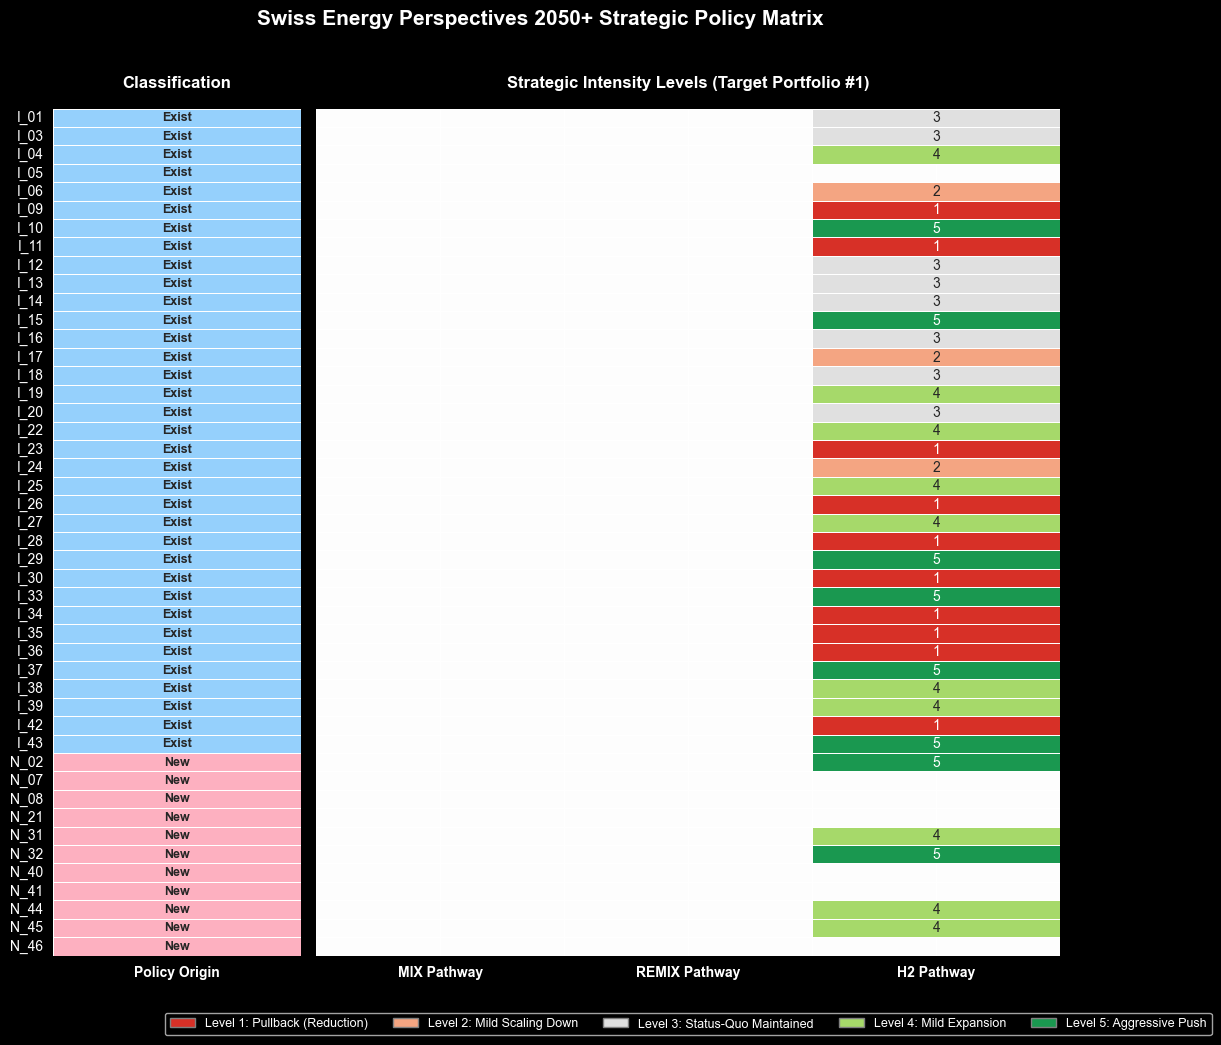

🎉 Matrix visualization fixed! Saved as 'Policy_Optimization_Matrix_Clean.png'.


In [12]:
# 1. Reconstruct all base policies in order to build our table rows
df_policies_clean['Base_ID'] = (
    df_policies_clean['Policy_ID'].apply(lambda x: "_".join(x.split('_')[:-1]))
)
all_base_policies = sorted(df_policies_clean['Base_ID'].unique())

# 2. Initialize an empty DataFrame for our heatmap table
# Rows = Base Policy IDs, Columns = Baseline status + the 3 strategic scenarios
matrix_cols = ['Status-Quo Type', 'MIX', 'REMIX', 'H2']
df_heatmap = pd.DataFrame(index=all_base_policies, columns=matrix_cols)

# 3. Populate Column 1: Existing vs. New Policy Classification
# Existing ("I") = 1, New ("N") = 0 (we will map colors to these numbers later)
for base_id in all_base_policies:
    df_heatmap.loc[base_id, 'Status-Quo Type'] = 1 if base_id.startswith('I') else 0

# 4. Populate Scenario Columns (Using Alternative #1 as our primary display portfolio)
# We map the chosen policy back to its raw numerical intensity level (1 to 5)
for scenario in ['MIX', 'REMIX', 'H2']:
    # Check if the optimization successfully generated a portfolio for this scenario
    if scenario in all_scenario_results and len(all_scenario_results[scenario]) > 0:
        # Pull the primary portfolio choice (Alternative #1)
        chosen_portfolio = all_scenario_results[scenario][0]

        for full_id in chosen_portfolio:
            # Extract base ID and intensity digit (e.g., 'I_01_3' -> base='I_01', intensity=3)
            parts = full_id.split('_')
            intensity_level = int(parts[-1])
            base_id = "_".join(parts[:-1])

            if base_id in df_heatmap.index:
                df_heatmap.loc[base_id, scenario] = intensity_level

# Fill any unselected or empty scenario cells with NaN (will display gray/white if unchosen)
df_heatmap[['MIX', 'REMIX', 'H2']] = df_heatmap[['MIX', 'REMIX', 'H2']].fillna(np.nan)

# Convert all cell types to floats for plotting compatibility
df_heatmap = df_heatmap.astype(float)


# 5. Set up customized discrete color maps
# Custom colormap for Column 1 (Type): [0 = Light Orange/New, 1 = Sky Blue/Existing]
cmap_type = sns.xkcd_palette(['soft pink', 'light blue'])

# Define a static 5-color list for our intensity spectrum
# Level 1: Dark Red | Level 2: Light Red | Level 3: Gray | Level 4: Light Green | Level 5: Dark Green
color_list = ["#d73027", "#f4a582", "#e0e0e0", "#a6d96a", "#1a9850"]
cmap_intensity = sns.color_palette(color_list)

# =============================================================================
# 6. Plotting the Structured Matrix (1 Column Per Scenario)
# =============================================================================
fig, (ax1, ax2) = plt.subplots(
    1, 2, figsize=(13, 11), gridspec_kw={'width_ratios': [1, 3], 'wspace': 0.03}
)

# --- Subplot A: Policy Origin Classification ---
sns.heatmap(
    df_heatmap[['Status-Quo Type']],
    ax=ax1,
    cmap=cmap_type,
    cbar=False,
    linewidths=0.5,
    linecolor='white',
    annot=True,
    fmt=".0f",
    annot_kws={'size': 9, 'weight': 'bold'},
)
ax1.set_xticklabels(['Policy Origin'], rotation=0, weight='bold')
ax1.set_title("Classification", weight='bold', pad=15)

# Convert 1 and 0 labels to clear string markers
for text in ax1.texts:
    text.set_text("Exist" if text.get_text() == "1" else "New")


# --- Subplot B: Scenario Intensities (Strict 1-to-1 Mapping) ---
# We explicitly isolate the scenarios to guarantee no column merging or duplication
scenarios_to_plot = ['MIX', 'REMIX', 'H2']

sns.heatmap(
    df_heatmap[scenarios_to_plot],
    ax=ax2,
    cmap=cmap_intensity,
    vmin=1,   # Forces Level 1 to map to color index 0
    vmax=5,   # Forces Level 5 to map to color index 4
    cbar=False,
    linewidths=0.5,
    linecolor='white',
    yticklabels=False,  # Turns off duplicate policy names on the right side
    annot=True,
    fmt=".0f",          # Prints the intensity number clearly inside the box
    mask=df_heatmap[scenarios_to_plot].isna(), # Leaves empty scenarios clean and blank
)

# Set clean, individual column labels
ax2.set_xticklabels(['MIX Pathway', 'REMIX Pathway', 'H2 Pathway'], rotation=0, weight='bold')
ax2.set_title("Strategic Intensity Levels (Target Portfolio #1)", weight='bold', pad=15)

# Masking adjustments: ensure empty cells display as a soft neutral background
ax2.set_facecolor('#fdfdfd')

# =============================================================================
# 7. Add Professional Legend Bench Matrix
# =============================================================================
from matplotlib.patches import Patch

legend_elements = [
    Patch(facecolor="#d73027", edgecolor="gray", label="Level 1: Pullback (Reduction)"),
    Patch(facecolor="#f4a582", edgecolor="gray", label="Level 2: Mild Scaling Down"),
    Patch(facecolor="#e0e0e0", edgecolor="gray", label="Level 3: Status-Quo Maintained"),
    Patch(facecolor="#a6d96a", edgecolor="gray", label="Level 4: Mild Expansion"),
    Patch(facecolor="#1a9850", edgecolor="gray", label="Level 5: Aggressive Push"),
]
ax2.legend(
    handles=legend_elements,
    bbox_to_anchor=(0.5, -0.06),
    loc="upper center",
    ncol=5,
    frameon=True,
    fontsize=9
)

plt.suptitle(
    "Swiss Energy Perspectives 2050+ Strategic Policy Matrix",
    fontsize=15,
    weight='bold',
    y=0.97,
)

# Save high-quality graphic for thesis inclusion
plt.savefig("Policy_Optimization_Matrix_Clean.png", dpi=300, bbox_inches='tight')
plt.show()

print("🎉 Matrix visualization fixed! Saved as 'Policy_Optimization_Matrix_Clean.png'.")

### 4.2 Generate csv file

In [13]:
# 1. Gather all unique base policy structures present in your master table
df_policies_clean['Base_ID'] = df_policies_clean['Policy_ID'].apply(lambda x: "_".join(x.split('_')[:-1]))
all_base_policies = sorted(df_policies_clean['Base_ID'].unique())

# 2. Build a clean raw data frame framework
csv_columns = ['Policy_Base_ID', 'Policy_Origin_Type', 'MIX', 'REMIX', 'H2']
df_csv_export = pd.DataFrame(index=all_base_policies, columns=csv_columns)
df_csv_export['Policy_Base_ID'] = df_csv_export.index

# 3. Classify policy taxonomic origin based on institutional tracking prefix
df_csv_export['Policy_Origin_Type'] = df_csv_export['Policy_Base_ID'].apply(
    lambda x: 'Exist' if x.startswith('I') else 'New'
)

# 4. Map numerical intensity values from Alternative #1 across target loops
for scenario in ['MIX', 'REMIX', 'H2']:
    if scenario in all_scenario_results and len(all_scenario_results[scenario]) > 0:
        # Pull your primary configuration structure (Alternative #1)
        primary_portfolio = all_scenario_results[scenario][0]

        for full_id in primary_portfolio:
            parts = full_id.split('_')
            intensity_level = int(parts[-1])
            base_id = "_".join(parts[:-1])

            if base_id in df_csv_export.index:
                df_csv_export.loc[base_id, scenario] = intensity_level

# 5. Save the output framework as a flat text comma-separated file
csv_output_filename = "Strategic_Policy_Optimization_Results.csv"
df_csv_export.to_csv(csv_output_filename, index=False)

print(f"📊 Raw numerical file successfully exported and saved as '{csv_output_filename}'!")

📊 Raw numerical file successfully exported and saved as 'Strategic_Policy_Optimization_Results.csv'!
